# Ανάλυση Δεδομένων Δημοπρασιών eBay

# Πρόβλεψη Τιμής Κλεισίματος (Regression)
* **Στόχος**: Η δημιουργία μοντέλων παλινδρόμησης για την πρόβλεψη της τελικής τιμής (`Price`) σε δημοπρασίες eBay.
* **Δεδομένα**: Χρησιμοποιούνται τα `TrainingSubset.csv` και `TestSubset.csv` (δημοπρασίες που κατέληξαν σε πώληση).

1. Εισαγωγή βιβλιοθηκών, εργαλειών και ρυθμίσεις περιβάλλοντος.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

2. Ορισμός συνάρτησης ελέγχου στηλών.

* Ορίζουμε τη συνάρτηση `find_useless_columns`. Αυτή δέχεται ένα DataFrame και μια λίστα εξαιρέσεων (`manual_exclude`) και επιστρέφει λίστα με στήλες που έχουν είτε μία μοναδική τιμή (σταθερές) είτε διαφορετική τιμή για κάθε γραμμή (IDs), ώστε να αφαιρεθούν αργότερα.

In [2]:
def find_useless_columns(df, manual_exclude):
    candidates = []
    total_rows = df.shape[0]
    
    for col in df.columns:
        if col in manual_exclude: 
            continue
            
        u_count = df.nunique()[col]
        
        if u_count <= 1 or u_count == total_rows:
            candidates.append(col)
            
    return candidates

3. Φόρτωση και ένωση δεδομένων.

* Φορτώνουμε τα αρχεία `TrainingSubset.csv` και `TestSubset.csv`. Προσθέτουμε τη στήλη `Source` για να διατηρήσουμε την προέλευση (Train/Test) και τα ενώνουμε σε ένα ενιαίο DataFrame (`df_reg`) για κοινή επεξεργασία.

In [3]:
base_path = os.getcwd()

try:
    df_train_sub = pd.read_csv('TrainingSubset.csv')
    df_test_sub = pd.read_csv('TestSubset.csv')
    
    print(f"Train Subset: {df_train_sub.shape}")
    print(f"Test Subset:  {df_test_sub.shape}")

    df_train_sub['Source'] = 'Train'
    df_test_sub['Source'] = 'Test'
    df_reg = pd.concat([df_train_sub, df_test_sub], axis=0, ignore_index=True)
    
    print(f"Merged DataFrame (df_reg): {df_reg.shape}")

except FileNotFoundError:
    print("Τα αρχεία csv δεν βρέθηκαν.")

Train Subset: (79732, 33)
Test Subset:  (9392, 33)
Merged DataFrame (df_reg): (89124, 34)


4. Καθαρισμός στηλών (IDs, Leakage & Multicollinearity).

*  **Manual:** Γνωστά IDs και Leakage.
*  **Static/IDs:** Στήλες με σταθερές ή μοναδικές τιμές.
*  **Target Correlation:** Συσχέτιση > 0.9 με το `Price` (Leakage).
*  **Feature Correlation:** Συσχέτιση > 0.9 μεταξύ τους (αν δύο στήλες λένε το ίδιο πράγμα, κρατάμε μόνο τη μία).

In [4]:
manual_drop = ['EbayID', 'PersonID', 'PricePercent', 'QuantitySold', 'ReturnsAccepted', 'BestOffer', 'PriceBuckets']
algo_candidates = find_useless_columns(df_reg, manual_exclude=['Price', 'Source'] + manual_drop)

corr_matrix = df_reg.corr(numeric_only=True).abs()

high_target_corr = corr_matrix.index[corr_matrix['Price'] > 0.9].tolist()
if 'Price' in high_target_corr: high_target_corr.remove('Price')

# Feature Correlation (>0.9 μεταξύ τους)
# Κοιτάμε μόνο το άνω τρίγωνο του πίνακα για να μην διπλομετρήσουμε
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_feature_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

final_drop = list(set(manual_drop + algo_candidates + high_target_corr + high_feature_corr))

print(f"Σύνολο στηλών προς διαγραφή: {len(final_drop)}")
print(f"Λίστα: {sorted(final_drop)}")

df_reg = df_reg.drop(columns=final_drop, errors='ignore')
print(f"Νέες διαστάσεις: {df_reg.shape}")

Σύνολο στηλών προς διαγραφή: 8
Λίστα: ['AuctionSaleCount', 'BestOffer', 'EbayID', 'PersonID', 'PriceBuckets', 'PricePercent', 'QuantitySold', 'ReturnsAccepted']
Νέες διαστάσεις: (89124, 26)


5. Ποιοτικός έλεγχος & feature engineering.

*  **Duplicates:** Αφαίρεση επαναλαμβανόμενων γραμμών.
*  **Missing Values:** Έλεγχος για ελλιπή δεδομένα.
*  **Outliers:** Αφαίρεση ακραίων τιμών (IQR) **αποκλειστικά από το Training Set**.
*  **Feature Engineering:** Αντικατάσταση των `SellerName` και `Category` με τη συχνότητα εμφάνισής τους (Frequency Encoding) για να αποφύγουμε τις χιλιάδες στήλες.
*  **Encoding:** Μετατροπή όλων των υπόλοιπων κατηγορικών και boolean μεταβλητών σε αριθμούς.

In [5]:
rows_before = df_reg.shape[0]
df_reg = df_reg.drop_duplicates()
print(f"Διπλότυπα που διαγράφηκαν: {rows_before - df_reg.shape[0]}")

nulls = df_reg.isnull().sum().sum()
print(f"Κενές Τιμές στο dataset: {nulls}")
# Αν υπάρχουν κενά, τα γεμίζουμε με 0
if nulls > 0:
    df_reg = df_reg.fillna(0)
    print("   -> Τα κενά γεμίστηκαν με 0.")

print(f"Διαστάσεις πριν τα Outliers: {df_reg.shape}")
numeric_cols = df_reg.select_dtypes(include=['number']).columns.tolist()
if 'Price' in numeric_cols: numeric_cols.remove('Price') # Δεν πειράζουμε τον στόχο

cols_filtered = []

for col in numeric_cols:
    # Αν η στήλη έχει μόνο 2 τιμές (π.χ. 0 και 1), είναι Binary.
    # ΔΕΝ πρέπει να σβήσουμε τα '1' ως outliers!
    if df_reg[col].nunique() <= 2:
        continue
    # Αν είναι συνεχής μεταβλητή (π.χ. HitCount), εφαρμόζουμε IQR
    # Υπολογισμός ορίων IQR μόνο στο Train 
    train_data = df_reg[df_reg['Source'] == 'Train'][col]
    Q1 = train_data.quantile(0.25)
    Q3 = train_data.quantile(0.75)
    IQR = Q3 - Q1
    # Αν το IQR είναι 0 (όλες οι τιμές ίδιες), δεν κάνουμε τίποτα
    if IQR == 0:
        continue
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    cols_filtered.append(col)
    
    # Κρατάμε: (Train που είναι OK) OR (ΟΛΟ το Test)
    condition_train = (df_reg['Source'] == 'Train') & (df_reg[col] >= lower) & (df_reg[col] <= upper)
    condition_test = (df_reg['Source'] == 'Test')
    
    df_reg = df_reg[condition_train | condition_test]
print(f"Εφαρμόστηκε φίλτρο Outliers σε {len(cols_filtered)} στήλες (εξαιρέθηκαν τα binaries).")
print(f"Διαστάσεις μετά τα Outliers: {df_reg.shape}")

# Μετράμε πόσο συχνά εμφανίζεται κάθε Seller και Category
df_reg['SellerName_Freq'] = df_reg.groupby('SellerName')['SellerName'].transform('count')
df_reg['Category_Freq'] = df_reg.groupby('Category')['Category'].transform('count')

df_reg = df_reg.drop(columns=['SellerName', 'Category'], errors='ignore')
print("Έγινε Frequency Encoding σε SellerName και Category.")

source_backup = df_reg['Source'] 
df_reg = df_reg.drop(columns=['Source']) 

bool_cols = df_reg.select_dtypes(include=['bool']).columns
df_reg[bool_cols] = df_reg[bool_cols].astype(int)

df_reg = pd.get_dummies(df_reg, drop_first=True)

df_reg['Source'] = source_backup

print(f"ΤΕΛΙΚΕΣ ΔΙΑΣΤΑΣΕΙΣ: {df_reg.shape}")

Διπλότυπα που διαγράφηκαν: 369
Κενές Τιμές στο dataset: 0
Διαστάσεις πριν τα Outliers: (88755, 26)
Εφαρμόστηκε φίλτρο Outliers σε 17 στήλες (εξαιρέθηκαν τα binaries).
Διαστάσεις μετά τα Outliers: (41270, 26)
Έγινε Frequency Encoding σε SellerName και Category.
ΤΕΛΙΚΕΣ ΔΙΑΣΤΑΣΕΙΣ: (41270, 31)


6. Διαχωρισμός σε Train και Test Sets.

    Χρησιμοποιούμε τη στήλη `Source` για να επαναφέρουμε τον διαχωρισμό των δεδομένων.
* **Train Set:** Χρησιμοποιείται για την εκπαίδευση του μοντέλου.
* **Test Set:** Χρησιμοποιείται για την αξιολόγηση.

    Διαχωρίζουμε επίσης τον στόχο (`y` = Price) από τα χαρακτηριστικά (`X`).

In [6]:
df_train_final = df_reg[df_reg['Source'] == 'Train']
df_test_final = df_reg[df_reg['Source'] == 'Test']

X_train = df_train_final.drop(columns=['Price', 'Source'])
y_train = df_train_final['Price']

X_test = df_test_final.drop(columns=['Price', 'Source'])
y_test = df_test_final['Price']

print("Ο διαχωρισμός ολοκληρώθηκε.")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape} | y_test shape:  {y_test.shape}")

Ο διαχωρισμός ολοκληρώθηκε.
X_train shape: (31910, 29) | y_train shape: (31910,)
X_test shape:  (9360, 29) | y_test shape:  (9360,)


7. Μοντέλο 1: Linear Regression.

*  **Standard Scaling:** Κανονικοποίηση των δεδομένων, ώστε όλες οι μεταβλητές να έχουν μέση τιμή 0 και τυπική απόκλιση 1. Αυτό είναι απαραίτητο για τη σωστή λειτουργία του αλγορίθμου.
*  **5-Fold Cross-Validation:** Χρησιμοποιούμε διασταυρωμένη επικύρωση (Validation) για να εκτιμήσουμε την απόδοση του μοντέλου στο Training Set και να ελέγξουμε για overfitting.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()

cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores) # Μετατροπή σε RMSE

print(f"Validation Results")
print(f"Mean CV RMSE: {cv_rmse.mean():.4f}")
print(f"Standard Deviation: {cv_rmse.std():.4f}")

lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Results")
print(f"Final RMSE: {rmse_lr:.4f}")
print(f"R2 Score: {r2_lr:.4f}")

Validation Results
Mean CV RMSE: 5.2242
Standard Deviation: 0.3842
Linear Regression Results
Final RMSE: 22.0328
R2 Score: 0.7196


8. Μοντέλο 2: Random Forest με GridSearchCV.

* **Grid Search:** Χρησιμοποιούμε `GridSearchCV` για να βρούμε τις βέλτιστες παραμέτρους (π.χ. `n_estimators`, `max_depth`).
* **Cross-Validation:** Το GridSearch κάνει αυτόματα 5-fold CV για κάθε συνδυασμό.
* **n_jobs=-1:** Χρησιμοποιούμε όλους τους πυρήνες του επεξεργαστή για ταχύτητα.

In [8]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    
    'max_depth': [10, 20, None],
    
    'min_samples_leaf': [1, 5]
}

grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5,                             
    n_jobs=-1,                        
    scoring='neg_mean_squared_error', 
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_rf_model = grid_search.best_estimator_
print(f"\nΒέλτιστες Παράμετροι: {grid_search.best_params_}")

y_pred_rf = best_rf_model.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Results")
print(f"Final RMSE: {rmse_rf:.4f}")
print(f"R2 Score: {r2_rf:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Βέλτιστες Παράμετροι: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest Results
Final RMSE: 34.1825
R2 Score: 0.3250


9. Σύγκριση μοντέλων & τελικά συμπεράσματα.

Τελικός Πίνακας Αποτελεσμάτων (Target: Price)


,Model,RMSE ($),R2 Score
0,Linear Regression,22.032815,0.719568
1,Random Forest (Tuned),34.182507,0.325013


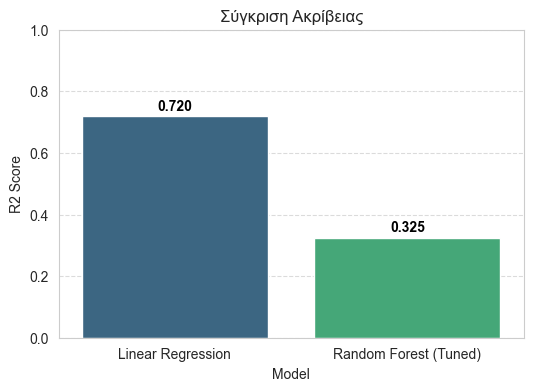


ΝΙΚΗΤΗΣ: Linear Regression με R2 = 0.7196
Διαφορά RMSE: 12.15 $


In [9]:
comparison_data = {
    'Model': ['Linear Regression', 'Random Forest (Tuned)'],
    'RMSE ($)': [rmse_lr, rmse_rf],          
    'R2 Score': [r2_lr, r2_rf]               
}

df_comparison = pd.DataFrame(comparison_data)

print("Τελικός Πίνακας Αποτελεσμάτων (Target: Price)")
display(df_comparison)

plt.figure(figsize=(6, 4))
sns.barplot(x='Model', y='R2 Score', data=df_comparison, palette='viridis')
plt.title('Σύγκριση Ακρίβειας')
plt.ylim(0, 1) 
plt.ylabel('R2 Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in df_comparison.iterrows():

    plt.text(index, row['R2 Score'] + 0.02, f"{row['R2 Score']:.3f}", 
             color='black', ha="center", fontweight='bold')

plt.show()

winner_idx = df_comparison['R2 Score'].idxmax()
winner_model = df_comparison.loc[winner_idx, 'Model']
winner_score = df_comparison.loc[winner_idx, 'R2 Score']

print(f"\nΝΙΚΗΤΗΣ: {winner_model} με R2 = {winner_score:.4f}")
print(f"Διαφορά RMSE: {abs(rmse_lr - rmse_rf):.2f} $")

# Πρόβλεψη Πώλησης (Classification)
* **Στόχος:** Η δημιουργία μοντέλων ταξινόμησης για την πρόβλεψη της έκβασης μιας δημοπρασίας, δηλαδή αν το προϊόν θα πουληθεί (`Sold = 1`) ή όχι (`Not Sold = 0`).
* **Δεδομένα:** Χρησιμοποιούνται τα `Trainingset.csv` και `Testset.csv` που περιλαμβάνουν όλες τις δημοπρασίες.

1. Εισαγωγή εργαλειών.

In [10]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix,
    ConfusionMatrixDisplay, 
    classification_report, 
    roc_auc_score, 
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

2. Φόρτωση και ένωση δεδομένων

* Φορτώνουμε τα αρχεία `Trainingset.csv` και `Testset.csv`. Προσθέτουμε τη στήλη `Source` για να διατηρήσουμε την προέλευση (Train/Test) και τα ενώνουμε σε ένα ενιαίο DataFrame (`df_class`) για κοινή επεξεργασία.

In [11]:
base_path = os.getcwd()

try:
    df_train_full = pd.read_csv('TrainingSet.csv')
    df_test_full = pd.read_csv('TestSet.csv')
    
    print(f"Train Set: {df_train_full.shape}")
    print(f"Test Set:  {df_test_full.shape}")

    df_train_full['Source'] = 'Train'
    df_test_full['Source'] = 'Test'
    
    df_class = pd.concat([df_train_full, df_test_full], axis=0, ignore_index=True)
    
    print(f"Merged DataFrame (df_class): {df_class.shape}")

except FileNotFoundError:
    print("Τα αρχεία δεν βρέθηκαν.")

Train Set: (258588, 28)
Test Set:  (37460, 28)
Merged DataFrame (df_class): (296048, 29)


3. Καθαρισμός στηλών (IDs, Leakage & Multicollinearity).

* **Manual IDs & Leakage:** Αφαιρούμε τα αναγνωριστικά (`EbayID`, `PersonID`) που είναι μοναδικά για κάθε εγγραφή. Επίσης, αφαιρούμε στήλες όπως το `Price`, `PricePercent` και `AvgPrice`, καθώς αυτές οι τιμές οριστικοποιούνται μόνο αν πραγματοποιηθεί η πώληση (Data Leakage).
* **Object Columns:** Στήλες κειμένου όπως `SellerName`, `Category` και `EndDay` αφαιρούνται για να αποφευχθεί το Overfitting (π.χ. το μοντέλο να "μαθαίνει" συγκεκριμένους πωλητές αντί για τη γενική συμπεριφορά της αγοράς).
* **Static/IDs:** Χρησιμοποιούμε τη συνάρτηση `find_useless_columns` για να εντοπίσουμε και να διαγράψουμε στήλες που έχουν την ίδια τιμή σε όλες τις γραμμές ή είναι μοναδικές για κάθε γραμμή.
* **Target Correlation:** Εντοπίζουμε στήλες με υπερβολική συσχέτιση (>0.9) με τον στόχο μας (`QuantitySold`), οι οποίες είναι ύποπτες για leakage και μπορούν να οδηγήσουν σε πλασματική ακρίβεια.
* **Feature Correlation:** Ελέγχουμε τη συσχέτιση μεταξύ των χαρακτηριστικών (Multicollinearity). Αν δύο στήλες έχουν συσχέτιση > 0.9, κρατάμε μόνο τη μία, ώστε να μην παρέχουμε διπλή πληροφορία που μπερδεύει τους αλγορίθμους.

In [12]:
manual_drop = ['EbayID', 'PersonID', 'Price', 'PricePercent', 'SellerName', 'Category', 'EndDay']

algo_candidates = find_useless_columns(df_class, manual_exclude=['QuantitySold', 'Source'] + manual_drop)

corr_matrix = df_class.corr(numeric_only=True).abs()

target_col = 'QuantitySold'
high_target_corr = corr_matrix.index[corr_matrix[target_col] > 0.9].tolist()
if target_col in high_target_corr: high_target_corr.remove(target_col)

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_feature_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

final_drop = list(set(manual_drop + algo_candidates + high_target_corr + high_feature_corr))

print(f"Σύνολο στηλών προς διαγραφή: {len(final_drop)}")
print(f"Λίστα: {sorted(final_drop)}")

df_class = df_class.drop(columns=final_drop, errors='ignore')
print(f"Νέες διαστάσεις (df_class): {df_class.shape}")

Σύνολο στηλών προς διαγραφή: 10
Λίστα: ['AuctionSaleCount', 'Category', 'EbayID', 'EndDay', 'PersonID', 'Price', 'PricePercent', 'ReturnsAccepted', 'SellerName', 'StartingBidPercent']
Νέες διαστάσεις (df_class): (296048, 19)


4. Ποιοτικός έλεγχος.

* **Duplicates:** Αφαίρεση επαναλαμβανόμενων γραμμών που τυχόν προέκυψαν.
* **Missing Values:** Έλεγχος για ελλιπή δεδομένα.
* **Διαχείριση Outliers:** Σε αντίθεση με πριν, **ΔΕΝ** αφαιρούμε τις ακραίες τιμές. 
Επιλέγουμε τη διατήρηση όλης της πληροφορίας (καθώς οι σπάνιες πωλήσεις μπορεί να εμφανίζουν ακραία χαρακτηριστικά) και τη διαχείρισή τους μέσω **Robust Scaling**.
* **Encoding:** Μετατροπή των Boolean μεταβλητών (True/False) σε δυαδική μορφή (0 και 1).

In [13]:
rows_before = df_class.shape[0]
df_class = df_class.drop_duplicates()
print(f"Διπλότυπα που διαγράφηκαν: {rows_before - df_class.shape[0]}")

nulls = df_class.isnull().sum().sum()
print(f"Κενές Τιμές στο dataset: {nulls}")
if nulls > 0:
    df_class = df_class.fillna(0)
    print("Τα κενά γεμίστηκαν με 0.")

# Διαχείριση Outliers
# ΔΕΝ αφαιρούμε σειρές. Η διαχείριση θα γίνει μέσω του RobustScaler παρακάτω
print(f"Σταθερότητα δεδομένων: Διατηρήθηκαν {df_class.shape[0]} γραμμές.")

bool_cols = df_class.select_dtypes(include=['bool']).columns
df_class[bool_cols] = df_class[bool_cols].astype(int)
print(f"Μετατροπή Boolean: Επηρεάστηκαν {len(bool_cols)} στήλες.")

print("\nΤύποι δεδομένων μετά τον έλεγχο:")
print(df_class.dtypes.value_counts())

Διπλότυπα που διαγράφηκαν: 36874
Κενές Τιμές στο dataset: 0
Σταθερότητα δεδομένων: Διατηρήθηκαν 259174 γραμμές.
Μετατροπή Boolean: Επηρεάστηκαν 0 στήλες.

Τύποι δεδομένων μετά τον έλεγχο:
int64      11
float64     7
object      1
Name: count, dtype: int64


5. Διαχωρισμός και κανονικοποίηση (Splitting & Scaling).

* **Split:** Διαχωρίζουμε τα δεδομένα σε Training και Test set χρησιμοποιώντας τη στήλη `Source`.
* **Feature Selection:** Απομονώνουμε τα χαρακτηριστικά (X) από τον στόχο (y = `QuantitySold`).
* **Robust Scaling:** Εφαρμόζουμε τον `RobustScaler` ο οποίος χρησιμοποιεί τη διάμεσο (median) και το ενδοτεταρτημοριακό εύρος (IQR). Αυτό διασφαλίζει ότι οι ακραίες τιμές (Outliers) που κρατήσαμε δεν θα επηρεάσουν αρνητικά την εκπαίδευση των μοντέλων.

In [14]:
train_final = df_class[df_class['Source'] == 'Train'].copy()
test_final = df_class[df_class['Source'] == 'Test'].copy()

X_train = train_final.drop(columns=['QuantitySold', 'Source'])
y_train = train_final['QuantitySold']

X_test = test_final.drop(columns=['QuantitySold', 'Source'])
y_test = test_final['QuantitySold']

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Ο διαχωρισμός ολοκληρώθηκε.")
print(f"X_train shape: {X_train_scaled.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test_scaled.shape} | y_test shape:  {y_test.shape}")

Ο διαχωρισμός ολοκληρώθηκε.
X_train shape: (222925, 17) | y_train shape: (222925,)
X_test shape:  (36249, 17) | y_test shape:  (36249,)


6. Μοντέλο 1: Logistic Regression.

* Εφαρμόζουμε τον αλγόριθμο Logistic Regression, ο οποίος αποτελεί το βασικό μοντέλο αναφοράς (Baseline) για προβλήματα δυαδικής κατηγοριοποίησης.

In [15]:
log_reg = LogisticRegression(max_iter=2000, solver="lbfgs")

param_grid = {
    'C': np.logspace(-3, 2, 6), 
    'class_weight': [None, 'balanced']
}

grid_log = GridSearchCV(
    estimator=log_reg, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1
)

grid_log.fit(X_train_scaled, y_train)
print(f"Βέλτιστες Παράμετροι: {grid_log.best_params_}")

best_log_tuned = grid_log.best_estimator_
y_pred_tuned = best_log_tuned.predict(X_test_scaled)
y_probs_tuned = best_log_tuned.predict_proba(X_test_scaled)[:, 1]

print("\nΑΠΟΤΕΛΕΣΜΑΤΑ TUNED LOGISTIC REGRESSION")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs_tuned):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Βέλτιστες Παράμετροι: {'C': np.float64(0.1), 'class_weight': None}

ΑΠΟΤΕΛΕΣΜΑΤΑ TUNED LOGISTIC REGRESSION
Accuracy: 0.8906
ROC-AUC Score: 0.9292

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     26932
           1       0.87      0.68      0.76      9317

    accuracy                           0.89     36249
   macro avg       0.88      0.82      0.85     36249
weighted avg       0.89      0.89      0.89     36249



7. Μοντέλο 2: Random Forest Classifier.

* **Μη Γραμμικότητα:** Μπορεί να εντοπίσει πολύπλοκες σχέσεις μεταξύ των χαρακτηριστικών που η Logistic Regression αδυνατεί να δείξει.
* **Hyperparameter Tuning:** Χρησιμοποιούμε τη μέθοδο `RandomizedSearchCV` για να βρούμε το βέλτιστο συνδυασμό παραμέτρων (βάθος δέντρου, αριθμός δέντρων) μέσα από 5-Fold Cross-Validation.
* **Feature Importance:** Μας επιτρέπει να δούμε ποια χαρακτηριστικά της δημοπρασίας (π.χ. HitCount, SellerRating) έπαιξαν τον σημαντικότερο ρόλο στην πρόβλεψη.

In [16]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_dist = {
    'n_estimators': [50, 100, 200],     # Αριθμός δέντρων
    'max_depth': [10, 20, None],        # Μέγιστο βάθος
    'min_samples_split': [2, 5],        # Ελάχιστα δείγματα για διαχωρισμό
    'min_samples_leaf': [1, 2]          # Ελάχιστα δείγματα σε κάθε "φύλλο"
}

# Δοκιμάζει 5 τυχαίους συνδυασμούς (n_iter=5)
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist, 
    n_iter=5, 
    cv=5, 
    scoring='accuracy', 
    random_state=42, 
    n_jobs=-1,
    verbose=1
)
rf_random.fit(X_train_scaled, y_train)

print(f"Καλύτερες παράμετροι: {rf_random.best_params_}")
# Βρίσκουμε τη θέση (index) του καλύτερου συνδυασμού παραμέτρων
best_index = rf_random.best_index_

cv_mean = rf_random.cv_results_['mean_test_score'][best_index]
cv_std = rf_random.cv_results_['std_test_score'][best_index]

best_rf = rf_random.best_estimator_

y_pred_rf = best_rf.predict(X_test_scaled)
y_probs_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

print("ΑΠΟΤΕΛΕΣΜΑΤΑ TUNED RANDOM FOREST")
print(f"CV Accuracy (Mean): {cv_mean:.4f} (+/- {cv_std * 2:.4f})")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Καλύτερες παράμετροι: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
ΑΠΟΤΕΛΕΣΜΑΤΑ TUNED RANDOM FOREST
CV Accuracy (Mean): 0.8803 (+/- 0.0034)
Accuracy: 0.9002
ROC-AUC Score: 0.9421

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93     26932
           1       0.85      0.74      0.79      9317

    accuracy                           0.90     36249
   macro avg       0.88      0.85      0.86     36249
weighted avg       0.90      0.90      0.90     36249



8. Τελική αξιολόγηση και οπτικοποίηση αποτελεσμάτων.

* **ROC Curves:** Σύγκριση της ικανότητας των δύο μοντέλων να διαχωρίζουν τις επιτυχημένες από τις αποτυχημένες δημοπρασίες.
* **Feature Importance:** Ποια χαρακτηριστικά επηρέασαν περισσότερο την απόφαση του Random Forest.
* **Confusion Matrix:** Αναλυτική απεικόνιση των σωστών και λανθασμένων προβλέψεων του τελικού μοντέλου.

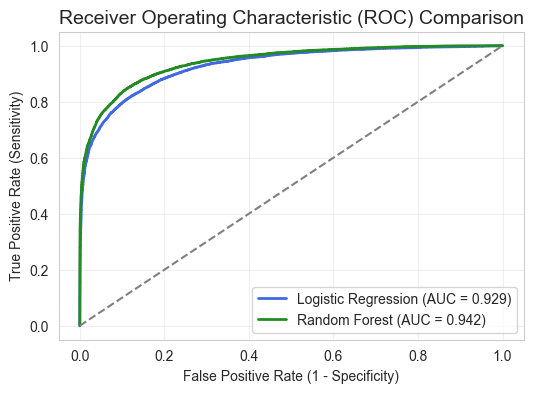

In [17]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_tuned)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr_log, tpr_log, color='royalblue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_probs_tuned):.3f})')
plt.plot(fpr_rf, tpr_rf, color='forestgreen', lw=2, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_probs_rf):.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title('Receiver Operating Characteristic (ROC) Comparison', fontsize=14)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

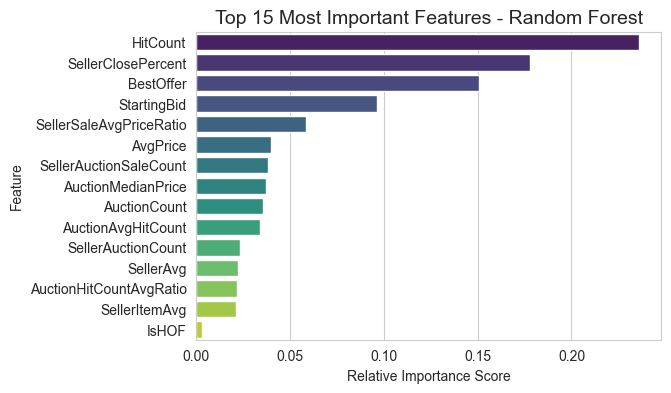

In [18]:
features = X_train.columns
importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')
plt.title('Top 15 Most Important Features - Random Forest', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.show()

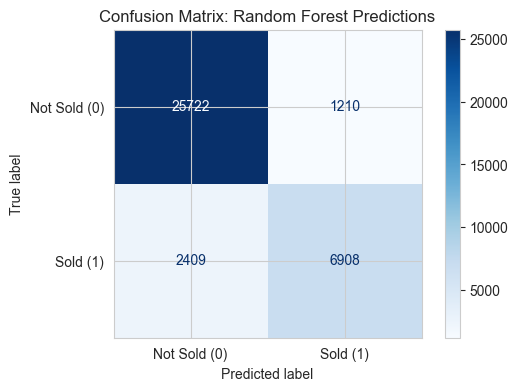

In [19]:
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Sold (0)', 'Sold (1)'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Confusion Matrix: Random Forest Predictions')
plt.show(); 

# Πρόβλεψη Εύρους Τιμής Πώλησης (Classification)
* **Στόχος:** Η δημιουργία μοντέλων ταξινόμησης για την πρόβλεψη του εύρους της τελικής τιμής, διαχωρίζοντας τις πωλήσεις σε "Υψηλή Τιμή" (1) και "Χαμηλή Τιμή" (0) με βάση τον μέσο όρο (`AvgPrice`).
* **Δεδομένα:** Χρησιμοποιείται το DataFrame `df_avgclass`, το οποίο απομονώνει μόνο τις επιτυχημένες πωλήσεις. Το DataFrame αυτό προέρχεται από το ήδη επεξεργασμένο σύνολο του πρώτου ερωτήματος, δεν απαιτείται επιπλέον προεπεξεργασία, διασφαλίζοντας την ταχύτητα και την αξιοπιστία της ανάλυσης.

1. Δημιουργία dataframe και feature engineering.

In [20]:
df_avgclass = df_reg.copy() 

df_avgclass['PriceLevel'] = (df_avgclass['Price'] >= df_avgclass['AvgPrice']).astype(int)

if 'AuctionEndTime' in df_avgclass.columns:
    df_avgclass['AuctionEndTime'] = pd.to_datetime(df_avgclass['AuctionEndTime'])
    df_avgclass['EndDay_Num'] = df_avgclass['AuctionEndTime'].dt.dayofweek
    df_avgclass['EndHour'] = df_avgclass['AuctionEndTime'].dt.hour

2. Καθαρισμός στηλών (IDs, leakage & multicollinearity).

* **Manual:** Αφαίρεση `Price`, `AvgPrice`, `PricePercent` (Leakage) και IDs.
* **Objects:** Διαγραφή στηλών κειμένου (`Category`, `SellerName`) για καλύτερη γενίκευση.
* **Static/Constant:** Αφαίρεση του `QuantitySold` (έχει πάντα τιμή 1 στο συγκεκριμένο σύνολο).
* **Target Correlation:** Εντοπισμός και αφαίρεση χαρακτηριστικών με συσχέτιση > 0.9 με το `PriceLevel`.
* **Feature Correlation:** Αφαίρεση στηλών με συσχέτιση > 0.9 με τον στόχο ή μεταξύ τους (Multicollinearity).

In [21]:
manual_drop_g = ['EbayID', 'PersonID', 'Price', 'AvgPrice', 'PricePercent', 'SellerName', 'Category', 'EndDay', 'QuantitySold', 'AuctionSaleCount']

algo_candidates_g = find_useless_columns(df_avgclass, manual_exclude=['PriceLevel'] + manual_drop_g)

corr_matrix_g = df_avgclass.corr(numeric_only=True).abs()

target_col_g = 'PriceLevel'
high_target_corr_g = corr_matrix_g.index[corr_matrix_g[target_col_g] > 0.9].tolist()
if target_col_g in high_target_corr_g: high_target_corr_g.remove(target_col_g)

upper_tri_g = corr_matrix_g.where(np.triu(np.ones(corr_matrix_g.shape), k=1).astype(bool))
high_feature_corr_g = [column for column in upper_tri_g.columns if any(upper_tri_g[column] > 0.9)]

final_drop_g = list(set(manual_drop_g + algo_candidates_g + high_target_corr_g + high_feature_corr_g))

print(f"Σύνολο στηλών προς διαγραφή (Task γ): {len(final_drop_g)}")
print(f"Λίστα: {sorted(final_drop_g)}")

df_avgclass = df_avgclass.drop(columns=final_drop_g, errors='ignore')
print(f"Νέες διαστάσεις (df_avgclass): {df_avgclass.shape}")

Σύνολο στηλών προς διαγραφή (Task γ): 11
Λίστα: ['AuctionMedianPrice', 'AuctionSaleCount', 'AvgPrice', 'Category', 'EbayID', 'EndDay', 'PersonID', 'Price', 'PricePercent', 'QuantitySold', 'SellerName']
Νέες διαστάσεις (df_avgclass): (41270, 29)


3. Διαχωρισμός και κανονικοποίηση δεδομένων.

* **One-Hot Encoding:** Μετατρέπουμε τυχόν εναπομείναντα κατηγορικά χαρακτηριστικά σε αριθμητικά (dummy variables), ώστε να είναι επεξεργάσιμα από τα μοντέλα.
* **Train-Test Split (80/20):** Χωρίζουμε τα δεδομένα σε σύνολο εκπαίδευσης και σύνολο ελέγχου. Χρησιμοποιούμε την παράμετρο `stratify`, η οποία διασφαλίζει ότι η αναλογία των "ακριβών" και "φθηνών" δημοπρασιών παραμένει ίδια και στα δύο σύνολα, αποφεύγοντας έτσι την μεροληψία (bias).
* **Standard Scaling:** Εφαρμόζουμε κανονικοποίηση στα δεδομένα. Αυτό είναι απαραίτητο (ειδικά για τη Logistic Regression), ώστε χαρακτηριστικά με μεγάλες τιμές (π.χ. Seller Rating) να μην επισκιάζουν χαρακτηριστικά με μικρότερες τιμές (π.χ. Bid Count).

In [22]:
from sklearn.model_selection import train_test_split

X_avg = df_avgclass.drop(columns=['PriceLevel'])
y_avg = df_avgclass['PriceLevel']

X_avg = pd.get_dummies(X_avg, drop_first=True)

X_train_avg, X_test_avg, y_train_avg, y_test_avg = train_test_split(X_avg, y_avg, test_size=0.2, random_state=42, stratify=y_avg)

scaler_avg = StandardScaler()
X_train_scaled_avg = scaler_avg.fit_transform(X_train_avg)
X_test_scaled_avg = scaler_avg.transform(X_test_avg)

print(f"Αριθμός χαρακτηριστικών (features): {X_train_scaled_avg.shape[1]}")

Αριθμός χαρακτηριστικών (features): 28


4. Μοντέλο 1: Logistic Regression.

* **Παράμετρος C:** Δοκιμάζουμε διαφορετικές τιμές για την παράμετρο κανονικοποίησης (regularization), ώστε να βρούμε τη χρυσή τομή μεταξύ της καλής προσαρμογής στα δεδομένα και της αποφυγής του overfitting.
* **Class Weight:** Εξετάζουμε αν η χρήση "balanced" βαρών βελτιώνει την ικανότητα του μοντέλου να αναγνωρίζει σωστά και τις δύο κλάσεις (High/Low Price), σε περίπτωση που υπάρχει ανισορροπία στα δεδομένα.

In [23]:
log_reg_avg = LogisticRegression(max_iter=2000, solver="lbfgs")

param_grid_lr = {
    'C': np.logspace(-3, 2, 6), 
    'class_weight': [None, 'balanced']
}

grid_log_avg = GridSearchCV(
    estimator=log_reg_avg, 
    param_grid=param_grid_lr, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1
)

grid_log_avg.fit(X_train_scaled_avg, y_train_avg)
print(f"Βέλτιστες Παράμετροι LR: {grid_log_avg.best_params_}")

best_log_avg = grid_log_avg.best_estimator_
y_pred_lr_avg = best_log_avg.predict(X_test_scaled_avg)
y_probs_lr_avg = best_log_avg.predict_proba(X_test_scaled_avg)[:, 1]

print("\nΑΠΟΤΕΛΕΣΜΑΤΑ TUNED LOGISTIC REGRESSION")
print(f"Accuracy: {accuracy_score(y_test_avg, y_pred_lr_avg):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test_avg, y_probs_lr_avg):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_avg, y_pred_lr_avg, target_names=['Low Price', 'High Price']))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Βέλτιστες Παράμετροι LR: {'C': np.float64(0.1), 'class_weight': None}

ΑΠΟΤΕΛΕΣΜΑΤΑ TUNED LOGISTIC REGRESSION
Accuracy: 0.8767
ROC-AUC Score: 0.9097

Classification Report:
              precision    recall  f1-score   support

   Low Price       0.90      0.95      0.92      6385
  High Price       0.78      0.63      0.70      1869

    accuracy                           0.88      8254
   macro avg       0.84      0.79      0.81      8254
weighted avg       0.87      0.88      0.87      8254



5. Μοντέλο 2: Random Forest Classifier.

* **Βελτιστοποίηση Παραμέτρων:** Αντί για εξαντλητική αναζήτηση (Grid Search), δοκιμάζουμε τυχαίους συνδυασμούς κρίσιμων παραμέτρων, όπως ο αριθμός των δέντρων (`n_estimators`) και το μέγιστο βάθος τους (`max_depth`), ώστε να βρούμε το βέλτιστο μοντέλο με μικρότερο υπολογιστικό κόστος.
* **Cross-Validation:** Η αξιολόγηση κατά την εκπαίδευση γίνεται με **5-Fold Cross-Validation**, εξασφαλίζοντας ότι το μοντέλο είναι σταθερό και δεν παρουσιάζει φαινόμενα overfitting.

In [24]:
rf_avg = RandomForestClassifier(random_state=42)

param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_random_avg = RandomizedSearchCV(
    estimator=rf_avg, 
    param_distributions=param_dist_rf, 
    n_iter=5, 
    cv=5, 
    scoring='accuracy', 
    random_state=42, 
    n_jobs=-1,
    verbose=1
)

rf_random_avg.fit(X_train_scaled_avg, y_train_avg)
print(f"Καλύτερες παράμετροι RF: {rf_random_avg.best_params_}")

best_index_avg = rf_random_avg.best_index_
cv_mean_avg = rf_random_avg.cv_results_['mean_test_score'][best_index_avg]
cv_std_avg = rf_random_avg.cv_results_['std_test_score'][best_index_avg]

best_rf_avg = rf_random_avg.best_estimator_
y_pred_rf_avg = best_rf_avg.predict(X_test_scaled_avg)
y_probs_rf_avg = best_rf_avg.predict_proba(X_test_scaled_avg)[:, 1]

print("\nΑΠΟΤΕΛΕΣΜΑΤΑ TUNED RANDOM FOREST")
print(f"CV Accuracy (Mean): {cv_mean_avg:.4f} (+/- {cv_std_avg * 2:.4f})")
print(f"Accuracy: {accuracy_score(y_test_avg, y_pred_rf_avg):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test_avg, y_probs_rf_avg):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_avg, y_pred_rf_avg, target_names=['Low Price', 'High Price']))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Καλύτερες παράμετροι RF: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

ΑΠΟΤΕΛΕΣΜΑΤΑ TUNED RANDOM FOREST
CV Accuracy (Mean): 0.9286 (+/- 0.0038)
Accuracy: 0.9269
ROC-AUC Score: 0.9732

Classification Report:
              precision    recall  f1-score   support

   Low Price       0.93      0.98      0.95      6385
  High Price       0.90      0.76      0.83      1869

    accuracy                           0.93      8254
   macro avg       0.92      0.87      0.89      8254
weighted avg       0.93      0.93      0.92      8254



6. Τελική αξιολόγηση και οπτικοποίηση αποτελεσμάτων.

* **ROC Curves:** Σύγκριση της ικανότητας των δύο μοντέλων να διαχωρίζουν τις επιτυχημένες από τις αποτυχημένες δημοπρασίες.
* **Feature Importance:** Ποια χαρακτηριστικά επηρέασαν περισσότερο την απόφαση του Random Forest.
* **Confusion Matrix:** Αναλυτική απεικόνιση των σωστών και λανθασμένων προβλέψεων του τελικού μοντέλου.

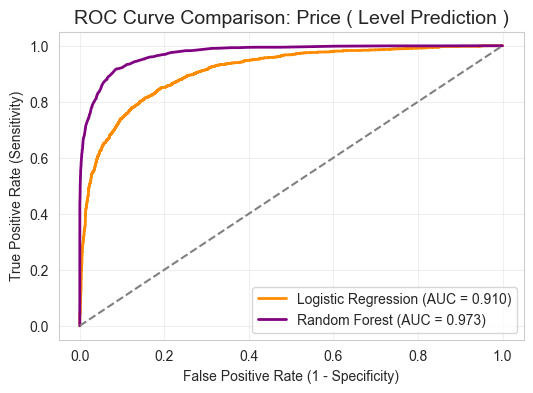

In [25]:
fpr_log_g, tpr_log_g, _ = roc_curve(y_test_avg, y_probs_lr_avg)
fpr_rf_g, tpr_rf_g, _ = roc_curve(y_test_avg, y_probs_rf_avg)

plt.figure(figsize=(6, 4))
plt.plot(fpr_log_g, tpr_log_g, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_score(y_test_avg, y_probs_lr_avg):.3f})')
plt.plot(fpr_rf_g, tpr_rf_g, color='purple', lw=2, label=f'Random Forest (AUC = {roc_auc_score(y_test_avg, y_probs_rf_avg):.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title('ROC Curve Comparison: Price ( Level Prediction )', fontsize=14)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

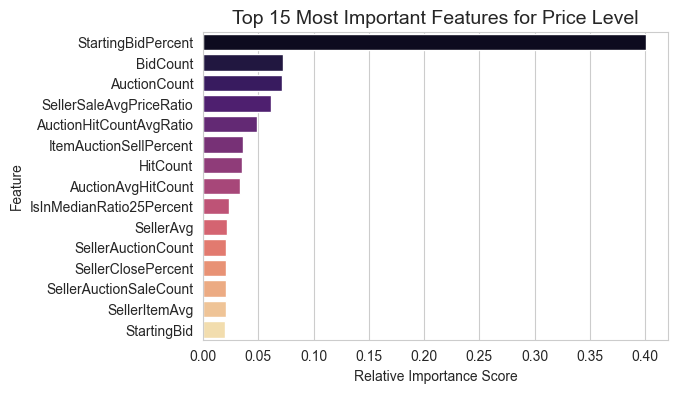

In [26]:
features_g = X_avg.columns
importances_g = best_rf_avg.feature_importances_
feat_imp_df_g = pd.DataFrame({'Feature': features_g, 'Importance': importances_g}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df_g.head(15), palette='magma')
plt.title('Top 15 Most Important Features for Price Level', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.show()

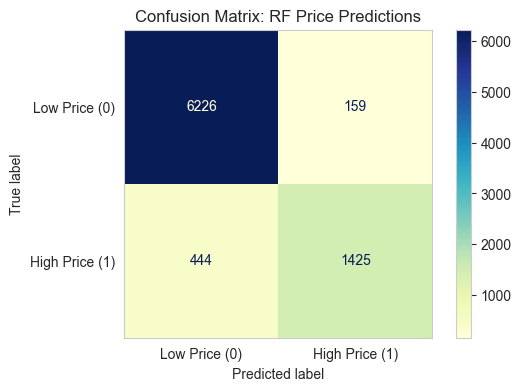

In [27]:
cm_g = confusion_matrix(y_test_avg, y_pred_rf_avg)

fig, ax = plt.subplots(figsize=(6, 4))
disp_g = ConfusionMatrixDisplay(confusion_matrix=cm_g, display_labels=['Low Price (0)', 'High Price (1)'])
disp_g.plot(cmap='YlGnBu', values_format='d', ax=ax)
plt.title('Confusion Matrix: RF Price Predictions')
plt.grid(False)
plt.show()

# Κατηγοριοποίηση Εικόνων CIFAR-10

* **Full Dataset (10 κλάσεις):** Για να φανεί η δυσκολία του προβλήματος.
* **Subset (2 κλάσεις):** Για να επιτευχθεί υψηλή ακρίβεια μέσω Grid Search.

1. Εισαγωγή βιβλιοθηκών, εργαλειών και ρυθμίσεις περιβάλλοντος.

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tarfile
import pickle
import urllib.request
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, auc

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

2. Λήψη και προετοιμασία δεδομένων.

* Κατεβάζει το `cifar-10-python.tar.gz`.
* Το αποσυμπιέζει.
* Διαβάζει τα binary αρχεία και τα μετατρέπει σε Pandas DataFrame.

In [29]:
url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
filename = "cifar-10-python.tar.gz"
data_dir = "cifar-10-batches-py"

if not os.path.exists(filename):
    print(f"Λήψη αρχείου από: {url}")
    try:
        urllib.request.urlretrieve(url, filename)
        print("Η λήψη ολοκληρώθηκε!")
    except Exception as e:
        print(f"Σφάλμα λήψης: {e}")
else:
    print(f"Το αρχείο '{filename}' υπάρχει ήδη.")

if not os.path.exists(data_dir):
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print("Η αποσυμπίεση ολοκληρώθηκε.")
else:
    print(f"Ο φάκελος '{data_dir}' υπάρχει ήδη.")

#(UNPICKLE)
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

X_parts = []
y_parts = []
batch_files = [f'data_batch_{i}' for i in range(1, 6)] + ['test_batch']

for batch_name in batch_files:
    file_path = os.path.join(data_dir, batch_name)
    if os.path.exists(file_path):
        d = unpickle(file_path)
        X_parts.append(d[b'data'])
        y_parts.append(d[b'labels'])

X_all = np.concatenate(X_parts)
y_all = np.concatenate(y_parts)

X_df = pd.DataFrame(X_all)

label_names = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
    5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}
y_series = pd.Series(y_all).map(label_names)

print(f"\nΦορτώθηκαν {X_df.shape[0]} εικόνες.")
print(f"Κλάσεις: {sorted(y_series.unique())}")

Το αρχείο 'cifar-10-python.tar.gz' υπάρχει ήδη.
Ο φάκελος 'cifar-10-batches-py' υπάρχει ήδη.

Φορτώθηκαν 60000 εικόνες.
Κλάσεις: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


3. Ανάλυση στο πλήρες dataset (10 Κλάσεις).
* Σε αυτή τη φάση χρησιμοποιούμε ένα δείγμα 5.000 εικόνων από όλες τις κλάσεις.
* Ο στόχος είναι να δείξουμε ότι το πρόβλημα είναι δύσκολο για απλούς αλγορίθμους όταν υπάρχουν πολλές κατηγορίες.

In [30]:
sample_size = 5000
X_full = X_df.sample(n=sample_size, random_state=42)
y_full = y_series.loc[X_full.index]

print(f"Χρήση δείγματος: {X_full.shape[0]} εικόνων")

le = LabelEncoder()
y_full_enc = le.fit_transform(y_full)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_full, y_full_enc, test_size=0.2, random_state=42, stratify=y_full_enc)

scaler_f = StandardScaler()
X_train_f_sc = scaler_f.fit_transform(X_train_f)
X_test_f_sc = scaler_f.transform(X_test_f)

results = []

lr = LogisticRegression(max_iter=500)
lr.fit(X_train_f_sc, y_train_f)
acc_lr = lr.score(X_test_f_sc, y_test_f)

y_probs_lr = lr.predict_proba(X_test_f_sc)
auc_lr = roc_auc_score(y_test_f, y_probs_lr, multi_class='ovr', average='macro')

results.append({'Model': 'Logistic Regression', 'Scenario': 'Full (10 Classes)', 'Accuracy': acc_lr, 'AUC': auc_lr})
print(f"Logistic Regression Accuracy: {acc_lr:.2%}, AUC: {auc_lr:.4f}")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_f_sc, y_train_f)
acc_rf = rf.score(X_test_f_sc, y_test_f)

y_probs_rf = rf.predict_proba(X_test_f_sc)
auc_rf = roc_auc_score(y_test_f, y_probs_rf, multi_class='ovr', average='macro')

results.append({'Model': 'Random Forest', 'Scenario': 'Full (10 Classes)', 'Accuracy': acc_rf, 'AUC': auc_rf})
print(f"Random Forest Accuracy: {acc_rf:.2%}, AUC: {auc_rf:.4f}")

Χρήση δείγματος: 5000 εικόνων
Logistic Regression Accuracy: 29.10%, AUC: 0.7208
Random Forest Accuracy: 36.10%, AUC: 0.7983


4. Ανάλυση σε Υποσύνολο (2 Κλάσεις).

* Επιλέγουμε μόνο τα **Αεροπλάνα** και τα **Αυτοκίνητα**.
* Εδώ εφαρμόζουμε **Grid Search** για να βρούμε τις βέλτιστες παραμέτρους.

In [31]:
class_1 = 'airplane'
class_2 = 'automobile'
print(f"Επιλογή: {class_1} vs {class_2}")

mask = y_series.isin([class_1, class_2])
X_sub = X_df[mask]
y_sub = y_series[mask]

if len(X_sub) > 5000:
    X_sub = X_sub.sample(n=5000, random_state=42)
    y_sub = y_sub.loc[X_sub.index]

print(f"Χρήση {X_sub.shape[0]} εικόνων για το υποσύνολο.")

le_sub = LabelEncoder()
y_sub_enc = le_sub.fit_transform(y_sub)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sub, y_sub_enc, test_size=0.2, random_state=42, stratify=y_sub_enc)

scaler_sub = StandardScaler()
X_train_s_sc = scaler_sub.fit_transform(X_train_s)
X_test_s_sc = scaler_sub.transform(X_test_s)

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), {'C': [0.1, 1, 10]}, cv=5)
grid_lr.fit(X_train_s_sc, y_train_s)

y_probs_lr_s = grid_lr.predict_proba(X_test_s_sc)[:, 1]
auc_lr_s = roc_auc_score(y_test_s, y_probs_lr_s)

results.append({
    'Model': 'Logistic Regression', 
    'Scenario': 'Subset (2 Classes)', 
    'Accuracy': grid_lr.best_score_,
    'AUC': auc_lr_s
})
print(f"Best Logistic Regression Accuracy: {grid_lr.best_score_:.2%}, AUC: {auc_lr_s:.4f}")

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), {'n_estimators': [50, 100], 'max_depth': [10, None]}, cv=5)
grid_rf.fit(X_train_s_sc, y_train_s)

y_probs_rf_s = grid_rf.predict_proba(X_test_s_sc)[:, 1]
auc_rf_s = roc_auc_score(y_test_s, y_probs_rf_s)

results.append({
    'Model': 'Random Forest', 
    'Scenario': 'Subset (2 Classes)', 
    'Accuracy': grid_rf.best_score_,
    'AUC': auc_rf_s
})
print(f"Best Random Forest Accuracy: {grid_rf.best_score_:.2%}, AUC: {auc_rf_s:.4f}")

Επιλογή: airplane vs automobile
Χρήση 5000 εικόνων για το υποσύνολο.
Best Logistic Regression Accuracy: 78.10%, AUC: 0.8633
Best Random Forest Accuracy: 86.27%, AUC: 0.9362


5. Συμπεράσματα και γραφήματα.


ΣΥΓΚΕΝΤΡΩΤΙΚΟΣ ΠΙΝΑΚΑΣ
                 Model            Scenario  Accuracy       AUC
0  Logistic Regression   Full (10 Classes)   0.29100  0.720813
1        Random Forest   Full (10 Classes)   0.36100  0.798333
2  Logistic Regression  Subset (2 Classes)   0.78100  0.863295
3        Random Forest  Subset (2 Classes)   0.86275  0.936160


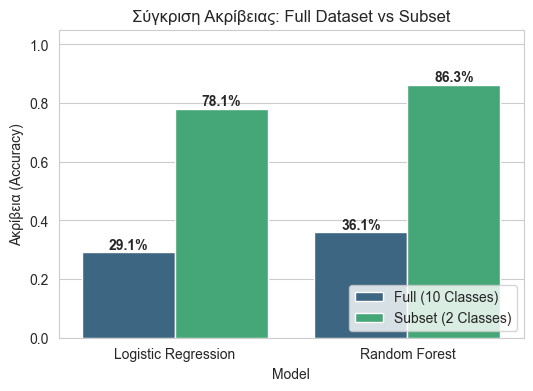

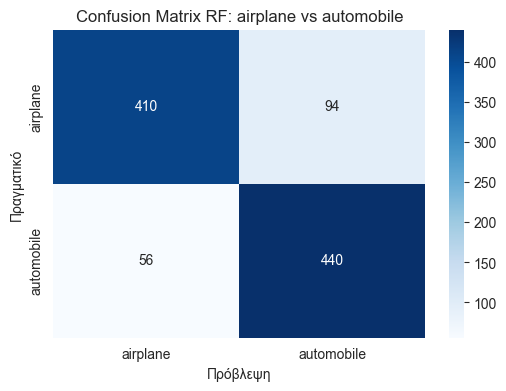

In [32]:
results_df = pd.DataFrame(results)

print("\nΣΥΓΚΕΝΤΡΩΤΙΚΟΣ ΠΙΝΑΚΑΣ")
print(results_df)

plt.figure(figsize=(6, 4))
sns.barplot(x='Model', y='Accuracy', hue='Scenario', data=results_df, palette='viridis')

plt.title('Σύγκριση Ακρίβειας: Full Dataset vs Subset')
plt.ylabel('Ακρίβεια (Accuracy)')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')

for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.1%}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.show()

best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_test_s_sc)
cm = confusion_matrix(y_test_s, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[class_1, class_2], yticklabels=[class_1, class_2])
plt.title(f'Confusion Matrix RF: {class_1} vs {class_2}')
plt.ylabel('Πραγματικό')
plt.xlabel('Πρόβλεψη')
plt.show()